# UBX Raw Measurement Parser

Parse u-blox binary (`.ubx`) recordings and extract **pseudorange** observations from `UBX-RXM-RAWX` messages.

**Data source:** `dataset/` folder — raw serial captures from u-blox receivers.

**Goal:** Plot pseudorange over time for every satellite tracked in the recording.

## 1. Install Dependencies

We use [`pyubx2`](https://github.com/semuconsulting/pyubx2) for parsing UBX binary protocol, and `matplotlib` + `pandas` for data wrangling and plotting.

In [1]:
!uv add pyubx2 pandas matplotlib

Resolved 17 packages in 4ms
Checked 15 packages in 0.32ms


## 2. Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pyubx2 import UBXReader

## 3. Parse UBX-RXM-RAWX Messages

`RXM-RAWX` contains raw GNSS measurements. For each epoch (receiver time-of-week) we extract:

| Field | Description |
|-------|-------------|
| `rcvTow` | Receiver time of week (seconds) |
| `gnssId` | GNSS constellation (0=GPS, 1=SBAS, 2=Galileo, 3=BeiDou, 5=QZSS, 6=GLONASS) |
| `svId` | Satellite vehicle number |
| `prMes` | Pseudorange measurement (meters) |
| `cno` | Carrier-to-noise ratio (dB-Hz) |

`pyubx2` parses the repeated measurement blocks and exposes fields with a `_XX` suffix (e.g. `prMes_01`, `gnssId_01`, …).

In [3]:
GNSS_NAMES = {0: "GPS", 1: "SBAS", 2: "GAL", 3: "BDS", 5: "QZSS", 6: "GLO"}

DATA_DIR = Path("dataset")
# UBX_FILE = DATA_DIR / "COM3___9600_260408_034104.ubx"
UBX_FILE = DATA_DIR / "COM4___9600_260408_034137.ubx"


def parse_rxm_rawx(filepath: Path) -> pd.DataFrame:
    """Parse all RXM-RAWX messages and return a flat DataFrame of measurements."""
    records = []

    with open(filepath, "rb") as f:
        reader = UBXReader(f, protfilter=2)  # UBX only
        for raw, parsed in reader:
            if parsed is None:
                continue
            if parsed.identity != "RXM-RAWX":
                continue

            msg = parsed.__dict__ if not hasattr(parsed, "val") else parsed.val
            rcv_tow = msg.get("rcvTow", None) or getattr(parsed, "rcvTow", None)
            num_meas = msg.get("numMeas", None) or getattr(parsed, "numMeas", None)

            if rcv_tow is None or num_meas is None:
                print("Available attrs:", [k for k in dir(parsed) if not k.startswith("_")])
                break

            for i in range(1, num_meas + 1):
                suffix = f"_{i:02d}"
                pr = msg.get(f"prMes{suffix}") or getattr(parsed, f"prMes{suffix}", None)
                cp = msg.get(f"cpMes{suffix}") or getattr(parsed, f"cpMes{suffix}", None)
                gnss_id = msg.get(f"gnssId{suffix}") or getattr(parsed, f"gnssId{suffix}", None)
                sv_id = msg.get(f"svId{suffix}") or getattr(parsed, f"svId{suffix}", None)
                cno = msg.get(f"cno{suffix}") or getattr(parsed, f"cno{suffix}", None)

                if isinstance(gnss_id, str):
                    constellation = gnss_id
                else:
                    constellation = GNSS_NAMES.get(gnss_id, f"GNSS{gnss_id}")

                if pr is not None and pr > 0:
                    records.append(
                        {
                            "rcvTow": rcv_tow,
                            "gnssId": gnss_id,
                            "svId": sv_id,
                            "constellation": constellation,
                            "sat": f"{constellation}{sv_id:02d}",
                            "prMes": pr,
                            "cpMes": cp,
                            "cno": cno,
                        }
                    )

    return pd.DataFrame(records)

df = parse_rxm_rawx(UBX_FILE)
print(f"Parsed {len(df)} measurements from {df['rcvTow'].nunique()} epochs, {df['sat'].nunique()} satellites")
df.head(10)

Available attrs: ['config_del', 'config_poll', 'config_set', 'identity', 'length', 'msg_cls', 'msg_id', 'msgmode', 'payload', 'serialize']
Parsed 1066 measurements from 153 epochs, 7 satellites


,rcvTow,gnssId,svId,constellation,sat,prMes,cpMes,cno
0,272521.0,0,4,GPS,GPS04,2.158478e+07,1.134287e+08,34
1,272521.0,0,5,GPS,GPS05,2.235566e+07,1.174797e+08,32
2,272521.0,0,9,GPS,GPS09,2.171071e+07,1.140905e+08,34
3,272521.0,0,6,GPS,GPS06,2.119344e+07,1.113723e+08,31
4,272521.0,0,8,GPS,GPS08,2.348967e+07,1.234390e+08,30
5,272521.0,0,19,GPS,GPS19,2.183814e+07,1.147602e+08,32
6,272521.0,0,30,GPS,GPS30,2.094067e+07,1.100440e+08,30
7,272522.0,0,4,GPS,GPS04,2.158555e+07,1.134328e+08,34
8,272522.0,0,5,GPS,GPS05,2.235628e+07,1.174830e+08,32
9,272522.0,0,9,GPS,GPS09,2.171109e+07,1.140925e+08,34


## 4. Plot Pseudorange Over Time

Each line represents one satellite. The x-axis is receiver time-of-week (seconds into the GPS week), and the y-axis is the pseudorange in meters.

Pseudorange values are typically in the range **~20,000 km – 26,000 km** for MEO GNSS satellites.

/var/folders/36/tkc64gps38s9nzp5s6dtqkpw0000gn/T/ipykernel_77650/3100178672.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(sats))


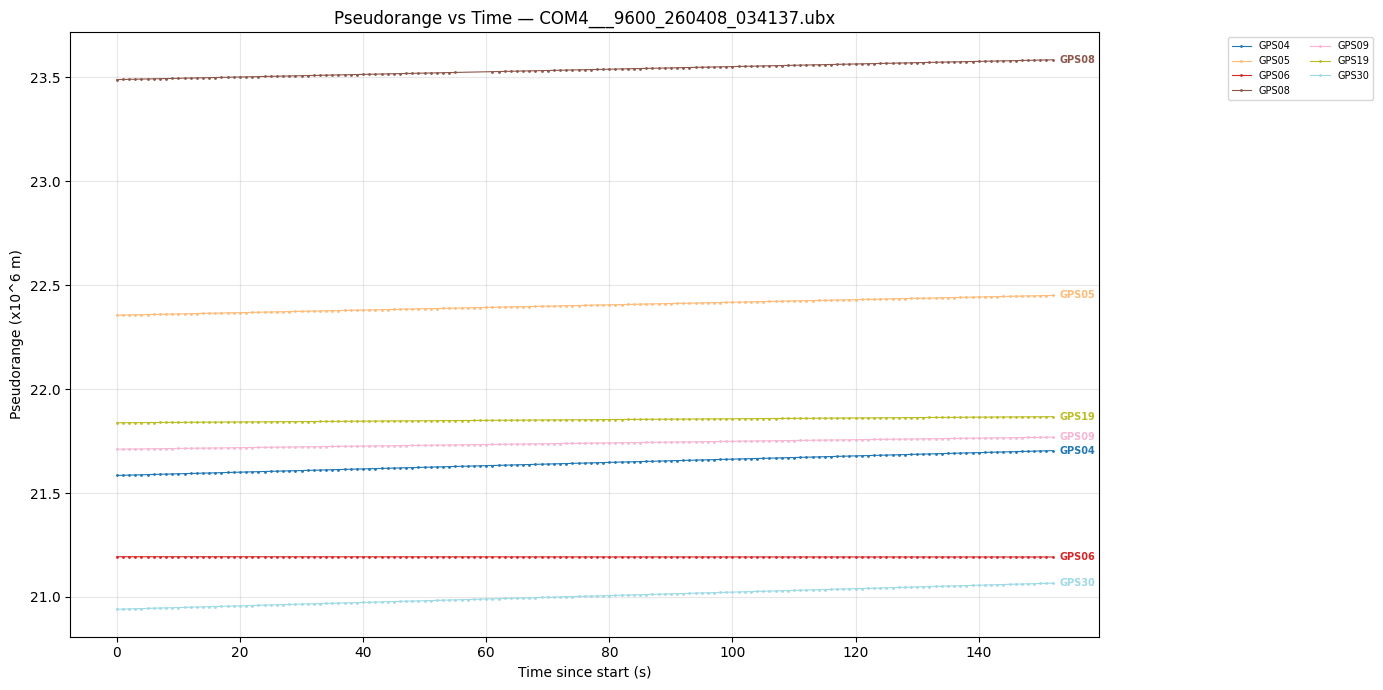

In [4]:
# Normalize time axis to start from 0
t0 = df["rcvTow"].min()
df["t_sec"] = df["rcvTow"] - t0

# Use a colormap with good perceptual separation
sats = sorted(df["sat"].unique())
cmap = plt.cm.get_cmap("tab20", len(sats))
colors = {sat: cmap(i) for i, sat in enumerate(sats)}

fig, ax = plt.subplots(figsize=(14, 7))

for sat in sats:
    grp = df[df["sat"] == sat].sort_values("t_sec")
    ax.plot(grp["t_sec"], grp["prMes"] / 1e6, label=sat, color=colors[sat],
            marker=".", markersize=2, linewidth=0.8)
    # Label PRN at the end of each line
    ax.annotate(sat, xy=(grp["t_sec"].iloc[-1], grp["prMes"].iloc[-1] / 1e6),
                fontsize=7, fontweight="bold", color=colors[sat],
                xytext=(5, 0), textcoords="offset points", va="center")

ax.set_xlabel("Time since start (s)")
ax.set_ylabel("Pseudorange (x10^6 m)")
ax.set_title(f"Pseudorange vs Time — {UBX_FILE.name}")
ax.legend(bbox_to_anchor=(1.12, 1), loc="upper left", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Summary Statistics

Quick overview: measurement count, mean C/N0, and pseudorange range per satellite.

In [5]:
summary = (
    df.groupby("sat")
    .agg(
        epochs=("rcvTow", "nunique"),
        mean_cno=("cno", "mean"),
        pr_min=("prMes", "min"),
        pr_max=("prMes", "max"),
    )
    .round(2)
    .sort_index()
)
summary["pr_range_km"] = ((summary["pr_max"] - summary["pr_min"]) / 1e3).round(2)
summary

,epochs,mean_cno,pr_min,pr_max,pr_range_km
sat,,,,,
GPS04,153,32.77,21584775.73,21704027.57,119.25
GPS05,153,31.12,22355660.26,22451065.78,95.41
GPS06,153,29.27,21192232.23,21193443.22,1.21
GPS08,148,28.63,23489665.30,23584946.57,95.28
GPS09,153,32.76,21710708.33,21769012.63,58.30
GPS19,153,28.40,21838143.06,21867442.80,29.30
GPS30,153,28.17,20940673.27,21066355.10,125.68


## 6. Carrier Phase Over Time

Carrier phase (`cpMes`) in cycles, plotted per satellite. Carrier phase is a much more precise (but ambiguous) range observable compared to pseudorange.

/var/folders/36/tkc64gps38s9nzp5s6dtqkpw0000gn/T/ipykernel_77650/3025819732.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(sats))


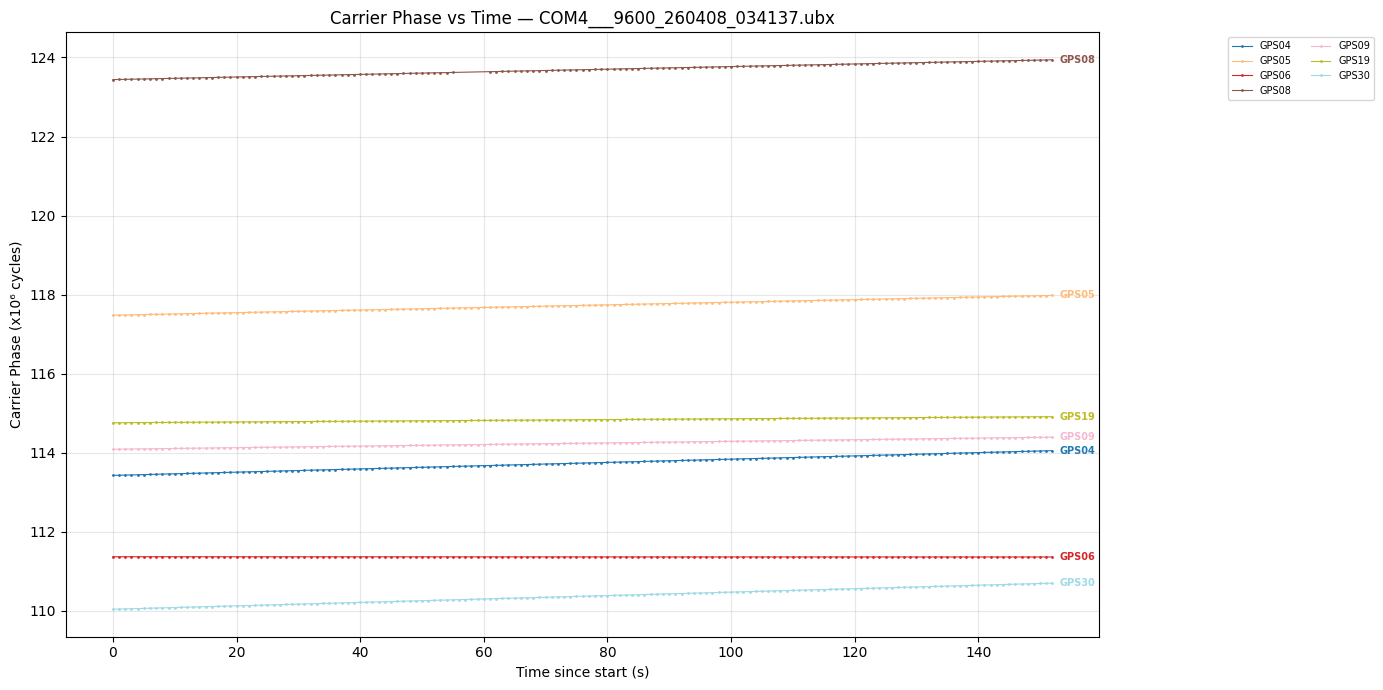

In [6]:
t0 = df["rcvTow"].min()
df["t_sec"] = df["rcvTow"] - t0

sats = sorted(df["sat"].unique())
cmap = plt.cm.get_cmap("tab20", len(sats))
colors = {sat: cmap(i) for i, sat in enumerate(sats)}

fig, ax = plt.subplots(figsize=(14, 7))

for sat in sats:
    grp = df[df["sat"] == sat].sort_values("t_sec")
    cp = grp["cpMes"].dropna()
    if cp.empty:
        continue
    ax.plot(grp.loc[cp.index, "t_sec"], cp / 1e6, label=sat, color=colors[sat],
            marker=".", markersize=2, linewidth=0.8)
    ax.annotate(sat, xy=(grp.loc[cp.index[-1], "t_sec"], cp.iloc[-1] / 1e6),
                fontsize=7, fontweight="bold", color=colors[sat],
                xytext=(5, 0), textcoords="offset points", va="center")

ax.set_xlabel("Time since start (s)")
ax.set_ylabel("Carrier Phase (x10⁶ cycles)")
ax.set_title(f"Carrier Phase vs Time — {UBX_FILE.name}")
ax.legend(bbox_to_anchor=(1.12, 1), loc="upper left", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 7. C/N0 Over Time

Carrier-to-noise density ratio (dB-Hz) per satellite. Higher C/N0 indicates a stronger, cleaner signal. Typical values range from ~25 dB-Hz (weak) to ~50 dB-Hz (strong, open sky).

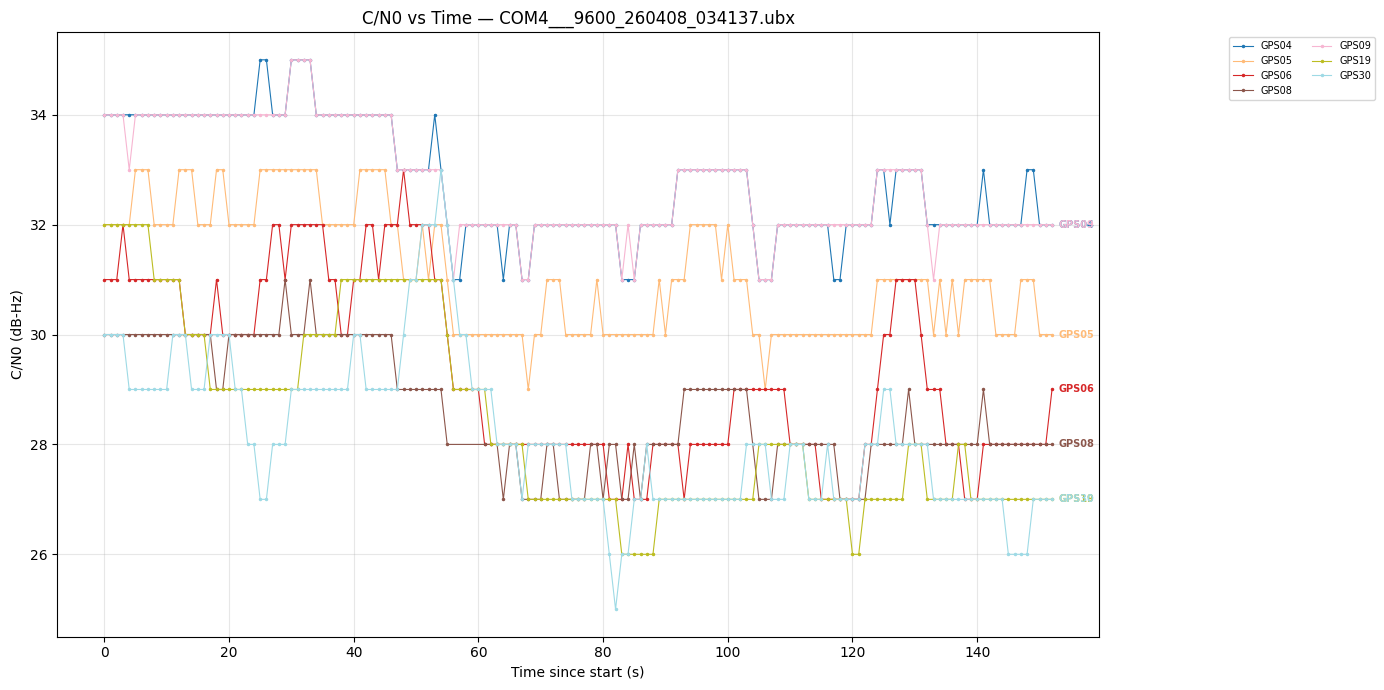

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

for sat in sats:
    grp = df[df["sat"] == sat].sort_values("t_sec")
    cno = grp["cno"].dropna()
    if cno.empty:
        continue
    ax.plot(grp.loc[cno.index, "t_sec"], cno, label=sat, color=colors[sat],
            marker=".", markersize=3, linewidth=0.8)
    ax.annotate(sat, xy=(grp.loc[cno.index[-1], "t_sec"], cno.iloc[-1]),
                fontsize=7, fontweight="bold", color=colors[sat],
                xytext=(5, 0), textcoords="offset points", va="center")

ax.set_xlabel("Time since start (s)")
ax.set_ylabel("C/N0 (dB-Hz)")
ax.set_title(f"C/N0 vs Time — {UBX_FILE.name}")
ax.legend(bbox_to_anchor=(1.12, 1), loc="upper left", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()